# Documents

Этап анализа документов

In [1]:
from src import QueryModel, llm, Model, lightrag_retrieve

query = QueryModel(
    settlement_name='Гатчина',
    settlement_type='город',
    current_year=2026
)

In [2]:
from pydantic import Field
from typing import Literal

class IndicatorModel(Model):
    """
    Целевой показатель
    """
    name : str = Field(description='Название показателя')
    unit : str = Field(description='Единица измерения')
    value : int | float = Field(description='Ожидаемое значение показателя')
    
    # values : list[IndicatorValueModel] = Field(min_length=1, description='Ожидаемые значения целевого показателя')

class IndicatorsModel(Model):
    """
    Целевые показатели, определяемые документом стратегии социально-экономического развития
    """
    indicators : list[IndicatorModel] = Field(min_length=1, description='Перечень основных целевых показателей документа')

class GoalSettingModel(Model):
    """
    Целеполагание документа стратегии социально-экономического развития.
    """
    problems : list[str] = Field(min_length=1, description='Основные вызовы и проблемы')
    goals : list[str] = Field(min_length=1, description='Перечень целей социально-экономического развития')
    priorities : list[str] = Field(min_length=1, description='Приоритеты пространственного и социально-экономического развития')


class InfoModel(Model):
    """
    Ключевые сведения о стратегии социально-экономического развития МО (района) или субъекта (при отсутствии стратегии МО), которую необходимо учитывать при разработке генерального плана.
    """
    name : str = Field('Название документа')
    start_year : int = Field(description='Расчетный срок начала действия документа')
    end_year : int = Field(description='Расчетный срок окончания действия документа (без учета прогноза)')


class DocumentState(Model):
    query : QueryModel
    info : InfoModel | None = None
    goal_setting : GoalSettingModel | None = None
    indicators : IndicatorsModel | None = None

In [3]:
from langchain.agents import create_agent

def info_node(state : DocumentState):
    agent = create_agent(
        model=llm,
        tools=[lightrag_retrieve],
        response_format=InfoModel,
    )
    response = agent.invoke({'messages': str(state.query)})
    return {
        'info': response['structured_response']
    }

def goal_setting_node(state : DocumentState):
    agent = create_agent(
        model=llm,
        tools=[lightrag_retrieve],
        response_format=GoalSettingModel,
    )
    message = {'query':state.query,'info':state.info}
    response = agent.invoke({'messages': str(message)})
    return {
        'goal_setting': response['structured_response']
    }

def indicators_node(state : DocumentState):
    agent = create_agent(
        model=llm,
        tools=[lightrag_retrieve],
        response_format=IndicatorsModel,
    )
    message = {'query':state.query,'info':state.info}
    response = agent.invoke({'messages': str(message)})
    return {
        'indicators': response['structured_response']
    }

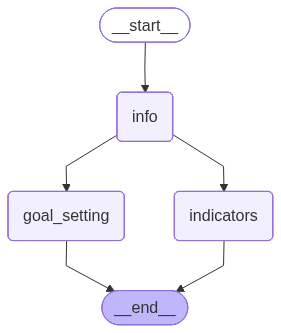

In [4]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

graph = StateGraph(DocumentState)

graph.add_node('info', info_node)
graph.add_node('goal_setting', goal_setting_node)
graph.add_node('indicators', indicators_node)

graph.add_edge(START, 'info')
graph.add_edge('info', 'goal_setting')
graph.add_edge('info', 'indicators')
graph.add_edge('goal_setting', END)
graph.add_edge('indicators', END)

app = graph.compile()
app

In [5]:
result = app.invoke({'query': query})

In [6]:
result

{'query': QueryModel(settlement_name='Гатчина', settlement_type='город', current_year=2026),
 'info': InfoModel(name='Стратегия социально-экономического развития Гатчинского муниципального района на период до 2030 года', start_year=2018, end_year=2030),
 'goal_setting': GoalSettingModel(problems=['Дисбалансы в социально-экономическом развитии между городскими и сельскими поселениями', 'Высокая степень износа объектов инженерной и коммунальной инфраструктуры', 'Снижение численности населения и рост естественной убыли', 'Дефицит мест в учреждениях детского дошкольного образования', 'Ограниченность ресурсов питьевого водоснабжения и ухудшение экологической ситуации', 'Высокая загрузка улично-дорожной сети и недостаточная пропускная способность', 'Отставание темпов роста экономики района от Санкт-Петербурга', 'Высокие темпы устаревания существующего жилищного фонда'], goals=['Повышение качества человеческого капитала на основе инновационного социально ориентированного типа экономического р

In [8]:
result['goal_setting']

GoalSettingModel(problems=['Дисбалансы в социально-экономическом развитии между городскими и сельскими поселениями', 'Высокая степень износа объектов инженерной и коммунальной инфраструктуры', 'Снижение численности населения и рост естественной убыли', 'Дефицит мест в учреждениях детского дошкольного образования', 'Ограниченность ресурсов питьевого водоснабжения и ухудшение экологической ситуации', 'Высокая загрузка улично-дорожной сети и недостаточная пропускная способность', 'Отставание темпов роста экономики района от Санкт-Петербурга', 'Высокие темпы устаревания существующего жилищного фонда'], goals=['Повышение качества человеческого капитала на основе инновационного социально ориентированного типа экономического развития', 'Создание многоотраслевого полюса роста инновационной экономики в рамках системы Санкт-Петербургской агломерации', 'Формирование эффективного диверсифицированного экономического комплекса с широким выбором рабочих мест', 'Качественное развитие инфраструктуры, д

In [16]:
import pickle

with open('./data/documents.pickle', 'wb') as file:
    pickle.dump(str(result), file)